# Corrected MP2 test
Since (in theory), the definition of virtual orbitals is now correct, as the orthonormalization scheme should be working, and leading to MO coefficients that diagonalize the $F_MO$ matrix, but keep the correct energies, we will test the implementation against PySCF's using the SCF coefficients obtained from the current implementation. 

In [1]:
# imports 
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map
from py_mods.src.SCF.scf_utils import _diagonalize_gram,  count_degen2
import matplotlib.pyplot as plt

from pathlib import Path

from pyscf.tools import molden

We will define the basis to use:

In [2]:
basis_names = [
    "cc-pvdz",
    "cc-pvtz",
    "cc-pvqz",
    "cc-pv5z",
    "aug-cc-pvdz",
    "aug-cc-pvtz",
    "aug-cc-pvqz",
    "aug-cc-pv5z",
    "def2-svp",
    "def2-tzvp",
    "def2-qzvp",
    "def2-svpd",
    "def2-tzvpd",
    "def2-qzvpd",
]

cc_basis = basis_names[0:8]

In [3]:
abs_errors = []
rel_errors = []
n_electrons = []

for basis in cc_basis:
    print(f'Calculating energy with {basis} basis set')

    pyscf_args = {
        "atom": "He 0 0 0",
        "spin": 0,
        "charge": 0,
        "basis": f"{basis}",
    }
    
    mol = gto.M(**pyscf_args) # , symmetry = False)
    mol.verbose = 0

    mf = scf.RHF(mol)
    
    # Tighten tighten tighten
    mf.conv_tol = 1e-14    
    mf.conv_tol_grad = 1e-14 
    mf.max_cycle = 100 

    e_He = mf.kernel()
    
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.conv_start = 30
    # RHF_cxt.conv_type = None
    RHF_cxt.threshold = 1e-14
    RHF_cxt.verbose = True

    RHF_res = CS_RHF(RHF_cxt)
    RHF_res.C_munu = RHF_res.C_munu.real

    # enforce pyscf mo energies and coefficients
    # RHF_res.C_munu = mf.mo_coeff
    # RHF_res.e_orb = mf.mo_energy
    
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))
    
    if abs_errors[-1] > 1E-6:
        print(np.max(RHF_res.C_munu.imag))
    
    max_eorb_diff = max(abs(RHF_res.e_orb - mf.mo_energy))
    print('Max orbital energy error:', max_eorb_diff)


Calculating energy with cc-pvdz basis set
--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00     0.0000E+00j
    1     -2.741897E+00+0.000000E+00j     -2.741897E+00+0.000000E+00j     5.2154E-01     0.0000E+00j
    2     -2.854410E+00+0.000000E+00j     -1.125131E-01+0.000000E+00j     4.3748E-02     0.0000E+00j
    3     -2.855156E+00+0.000000E+00j     -7.462188E-04+0.000000E+00j     3.3352E-03     0.0000E+00j
    4     -2.855160E+00+0.000000E+00j     -4.329924E-06+0.000000E+00j     2.5273E-04     0.0000E+00j
------------------------------    STARTED DIIS   -----------------


---

These are outputs for both cases using `eig` and `eigh`. The orbital energy differences with the reference are:

```
# Output Using eig:
Max orbital energy error: 1.0377032566566413e-11
Max orbital energy error: 1.6783445744295022e-09
Max orbital energy error: 1.3538103971200144e-08
Max orbital energy error: 5.896890797885135e-08
Max orbital energy error: 4.5296184580934096e-09
Max orbital energy error: 1.3467721871052163e-07
Max orbital energy error: 1.0339384104440796e-07
Max orbital energy error: 1.3600084969311865e-07
Max orbital energy error: 8.745226764972358e-12

# Output using eigh:
Max orbital energy error: 1.0377032566566413e-11
Max orbital energy error: 1.678336580823725e-09
Max orbital energy error: 1.3538105747556983e-08
Max orbital energy error: 5.896893640056078e-08
Max orbital energy error: 4.52961668173657e-09
Max orbital energy error: 1.346772311450195e-07
Max orbital energy error: 1.0339384104440796e-07
Max orbital energy error: 1.3600089943111016e-07
Max orbital energy error: 8.745670854182208e-12
```

Conclusion: both eig and eigh yield the correct eigenvalues and orbital energies are not a good metric to compare diagonalization schemes.


However, the resulting eigenvectors are not the same and result in MP2 errors. Using `eig`:

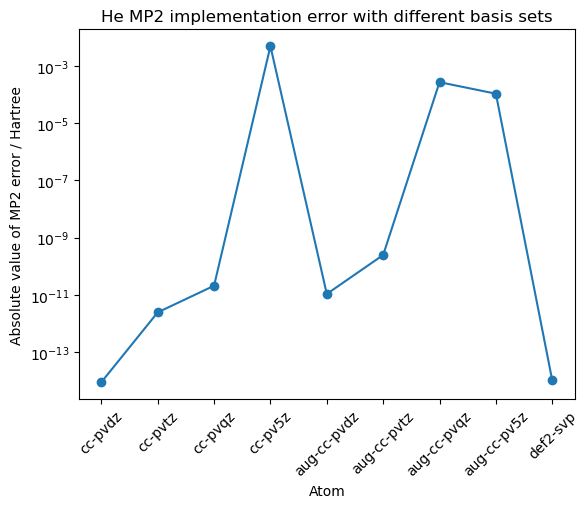


and using `eigh`:

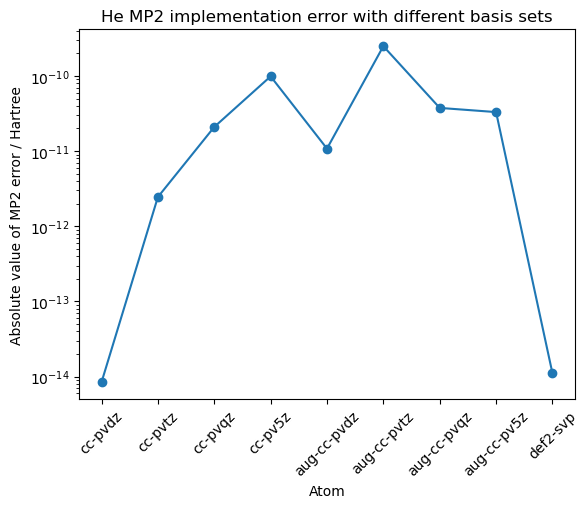

however, enforcing pyscf's mo energies and coefficients:

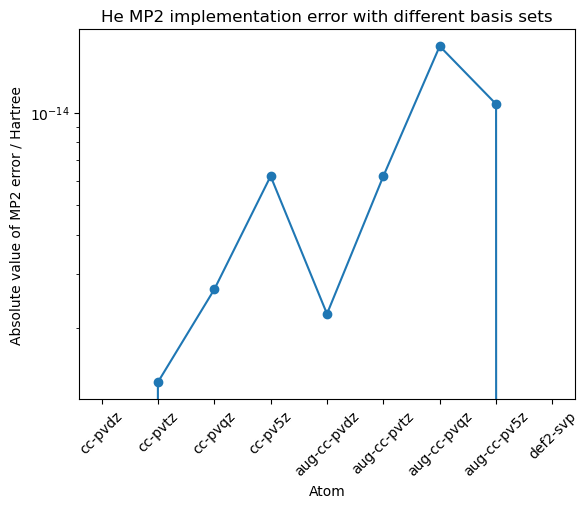

Thus the MP2 logic is correct. There must be something else going on in the SCF level. 

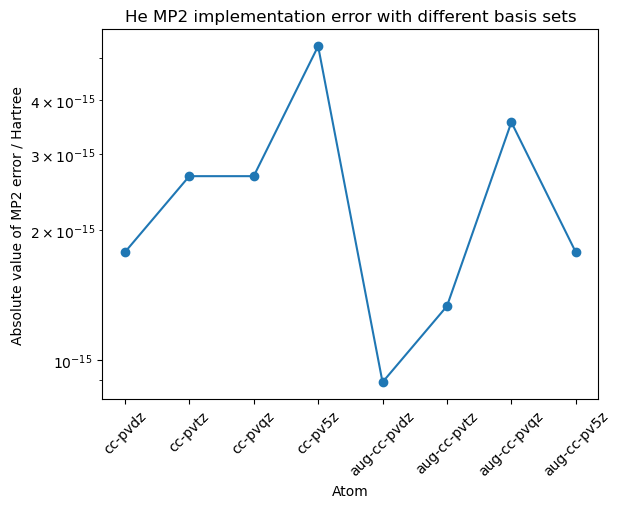

In [4]:
abs_errors = [abs(i) for i in abs_errors]
plt.plot(cc_basis, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"He MP2 implementation error with different basis sets")
plt.yscale('log')
plt.ylabel("Absolute value of MP2 error / Hartree")
plt.xlabel("Atom")
plt.xticks(rotation=45)

plt.show()

In [5]:
print(max(abs_errors))

5.329070518200751e-15


In [6]:
abs_errors = []
rel_errors = []
n_electrons = []

for basis in cc_basis:
    print(f'Calculating energy with {basis} basis set')

    pyscf_args = {
        "atom": "Ne 0 0 0",
        "spin": 0,
        "charge": 0,
        "basis": f"{basis}",
    }
    
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)
    
    # Tighten tighten tighten
    mf.conv_tol = 1e-14    
    mf.conv_tol_grad = 1e-14 
    mf.max_cycle = 100 

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-8

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))

    if abs_errors[-1] > 1E-6:
        print(np.max(RHF_res.C_munu.imag))


Calculating energy with cc-pvdz basis set
Calculating energy with cc-pvtz basis set
Calculating energy with cc-pvqz basis set
Calculating energy with cc-pv5z basis set
Calculating energy with aug-cc-pvdz basis set
Calculating energy with aug-cc-pvtz basis set
Calculating energy with aug-cc-pvqz basis set
Calculating energy with aug-cc-pv5z basis set


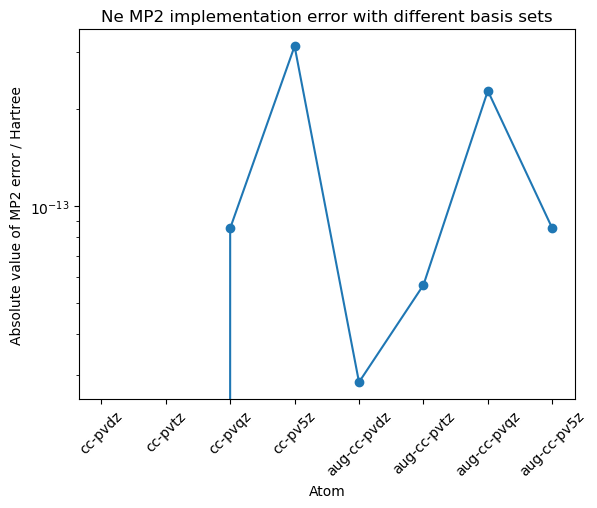

In [7]:
abs_errors = [abs(i) for i in abs_errors]
plt.plot(cc_basis, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"Ne MP2 implementation error with different basis sets")
plt.yscale('log')
plt.ylabel("Absolute value of MP2 error / Hartree")
plt.xlabel("Atom")
plt.xticks(rotation=45)

plt.show()

In [8]:
abs_errors = []
rel_errors = []
n_electrons = []

for basis in cc_basis:
    print(f'Calculating energy with {basis} basis set')

    pyscf_args = {
        "atom": "Ar 0 0 0",
        "spin": 0,
        "charge": 0,
        "basis": f"{basis}",
    }
    
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)

    # Tighten tighten tighten
    mf.conv_tol = 1e-14    
    mf.conv_tol_grad = 1e-14 
    mf.max_cycle = 100 

    e_He = mf.kernel()

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7
    
    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot) * 100 / mymp.e_tot))
    if abs_errors[-1] > 1E-6:
        print(np.max(RHF_res.C_munu.imag))


Calculating energy with cc-pvdz basis set
Calculating energy with cc-pvtz basis set
Calculating energy with cc-pvqz basis set
Calculating energy with cc-pv5z basis set
Calculating energy with aug-cc-pvdz basis set
Calculating energy with aug-cc-pvtz basis set
Calculating energy with aug-cc-pvqz basis set
Calculating energy with aug-cc-pv5z basis set


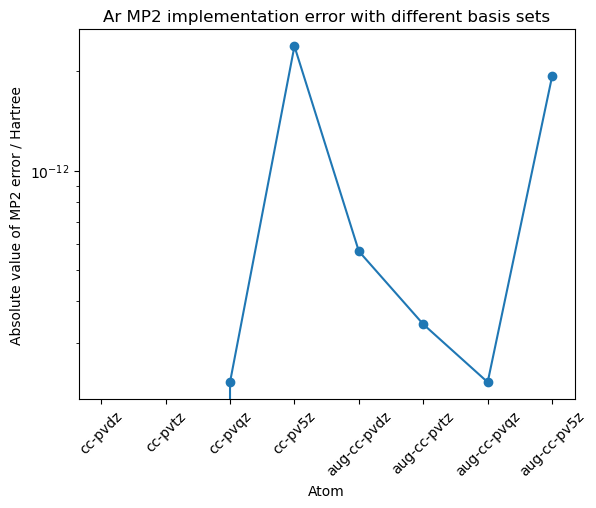

In [9]:
abs_errors = [abs(i) for i in abs_errors]
plt.plot(cc_basis, np.array(abs_errors).real, marker="o", linestyle="-")

plt.title(f"Ar MP2 implementation error with different basis sets")
plt.yscale('log')
plt.ylabel("Absolute value of MP2 error / Hartree")
plt.xlabel("Atom")
plt.xticks(rotation=45)

plt.show()

# Where does this come from? 
Since the smallest failing case is He/aug-cc-pvqz, lets try to understand where the differences might be:

In [ ]:
from pyscf import gto, scf, mp
import numpy as np
from Dev.CSMP2_dev import CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_mo_analysis, plot_map

In [11]:
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"cc-pv5z",
}

mol = gto.M(**pyscf_args)
mol.verbose = 0

mf = scf.RHF(mol)

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run()  # this is UMP2

# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_cxt.verbose = True
RHF_cxt.conv_type = None
RHF_cxt.max_iter = 18
RHF_res = CS_RHF(RHF_cxt)
print('Number of orbitals is: ', len(RHF_res.X))
mp_results = CS_MP2(RHF_res)

MP2_error = (mymp.e_tot - mp_results.E_MP2)
print('He/aug-cc-pvqz MP2 error:', MP2_error)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
    0     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00     0.0000E+00j
    1     -2.750010E+00+0.000000E+00j     -2.750010E+00+0.000000E+00j     6.3388E-01     0.0000E+00j
    2     -2.860252E+00+0.000000E+00j     -1.102420E-01+0.000000E+00j     5.2768E-02     0.0000E+00j
    3     -2.861591E+00+0.000000E+00j     -1.339265E-03+0.000000E+00j     7.3467E-03     0.0000E+00j
    4     -2.861624E+00+0.000000E+00j     -3.265637E-05+0.000000E+00j     1.1932E-03     0.0000E+00j
    5     -2.861625E+00+0.000000E+00j     -1.191581E-06+0.000000E+00j     2.1577E-04     0.0000E+00j
    6  

In [12]:
mp2_contribution = mp_results.t2_abrs

In [13]:
print(np.max(mp2_contribution))
print('Indices of max contribution:', np.unravel_index(np.argmax(mp2_contribution, axis=None), mp2_contribution.shape))

0.0035032707146946188
Indices of max contribution: (np.int64(0), np.int64(0), np.int64(4), np.int64(4))


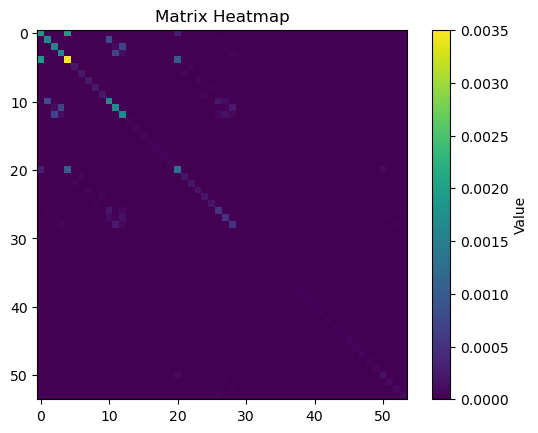

In [14]:
plot_map(mp2_contribution[0,0,:,:])

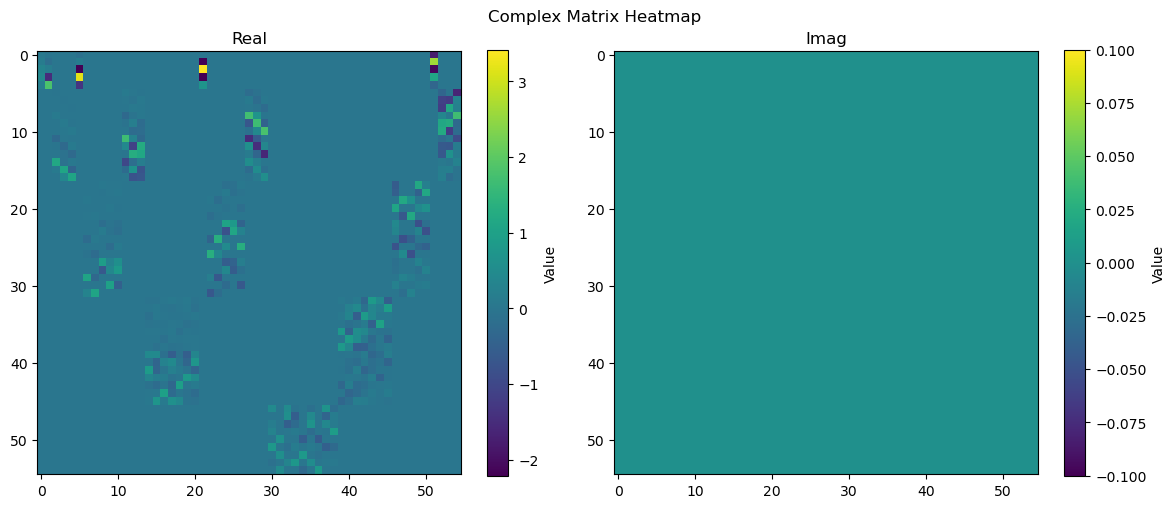

max of imag part of coefficient matrix is  0.0


In [15]:
plot_map(RHF_res.C_munu)
print('max of imag part of coefficient matrix is ', np.max(RHF_res.C_munu.imag))

With an imaginary part that should not be